# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

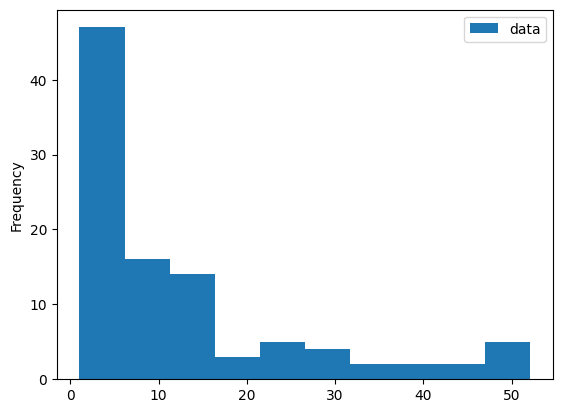

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

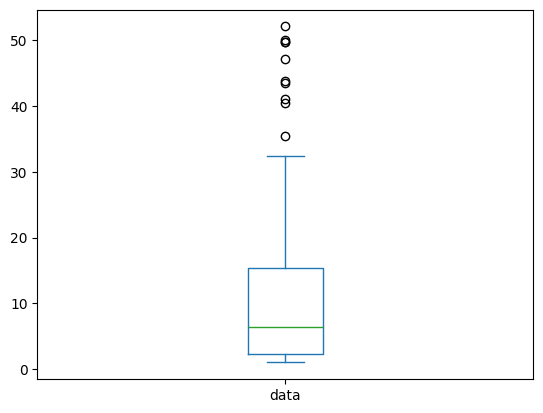

In [3]:
df.plot.box()

**Pros/cons**

- **Histogram:** Great for seeing the overall shape (skew, multiple peaks, gaps) and roughly how many drugs fall into different price ranges. Downsides: the impression can change a lot with the bin width, and with strongly right‑skewed price data the high-price tail can be hard to see/compare unless you use careful binning.
- **Boxplot:** Great for a quick summary (median, IQR, and outliers), which is useful if the administrator specifically cares about “more expensive drugs” relative to typical prices. Downsides: it hides the detailed distribution shape (e.g., whether there are two clusters of prices), and outlier points don’t tell you *how many* expensive drugs are in each region.



If the goal is understanding how expensive drugs compare to the rest, I’d choose the **boxplot** (it highlights the upper quartile and outliers immediately). If I could show only one, boxplot is faster for this decision; if I could show two, I’d pair it with a histogram (or log‑histogram) to preserve the distribution shape.

**Formatting improvements**

- Add clear axis labels and units (e.g., “Drug price (USD)”).
- Consider a **log scale** on the price axis for the histogram (or use log-binned histogram) since prices are typically right-skewed.
- On the boxplot, optionally **overlay jittered points** (strip/swarm) so the administrator can see how dense the expensive tail is, not just that it exists.
- Add reference lines/annotations for key cutoffs (median, 75th percentile, and maybe a “high-cost” threshold).

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import matplotlib.pyplot as plt
from pathlib import Path

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset 1: U.S. E Commerce Records

In [5]:
# Load Dataset
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1


### Variable 1: Sales per Customer

In [6]:
# Load the CSV file into a DataFrame
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.rglob("*.csv"))

data_file = csv_files[0]

df = pd.read_csv(data_file, encoding="cp1252")

# Aggregate data by Customer ID
customer_summary = df.groupby("Customer ID").agg({
"Order ID": "nunique",
"Quantity": "sum",
"Sales": "sum",
"Profit": "sum"
}).reset_index()

print("Customer summary:")
display(customer_summary.head())

customer_summary.describe()

Customer summary:


,Customer ID,Order ID,Quantity,Sales,Profit
0,AA-10315,1,5,374.480,96.5050
1,AA-10375,2,13,206.732,68.9195
2,AA-10480,1,3,15.552,5.4432
3,AA-10645,1,2,12.960,6.2208
4,AB-10060,4,31,2936.264,477.8292


,Order ID,Quantity,Sales,Profit
count,693.000000,693.000000,693.000000,693.000000
mean,2.434343,18.002886,1058.030671,134.833001
std,1.307085,12.960701,1463.910713,559.192347
min,1.000000,1.000000,1.188000,-3825.339400
25%,1.000000,8.000000,204.405000,5.176100
50%,2.000000,16.000000,604.910000,58.778000
75%,3.000000,25.000000,1334.641600,199.168200
max,8.000000,92.000000,14203.278000,6780.896300


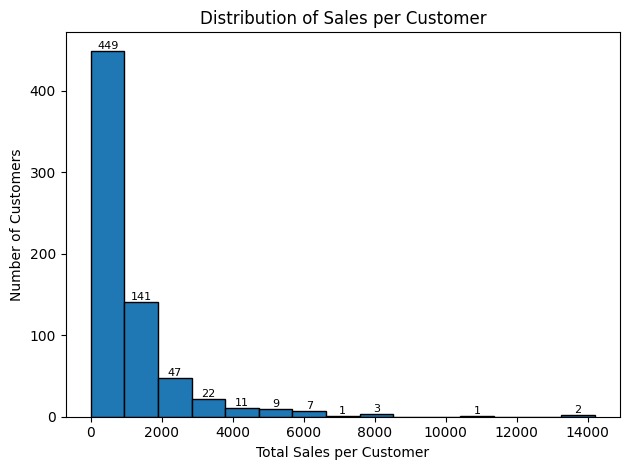

In [7]:
# Plot histogram of Sales per Customer
counts, bins, patches = plt.hist(customer_summary["Sales"], bins=15, edgecolor='black')

for count, patch in zip(counts, patches):
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width()/2, height,
                 int(height),
                 ha='center', va='bottom', fontsize=8)

plt.xlabel("Total Sales per Customer")
plt.ylabel("Number of Customers")
plt.title("Distribution of Sales per Customer")
plt.tight_layout()
plt.show()


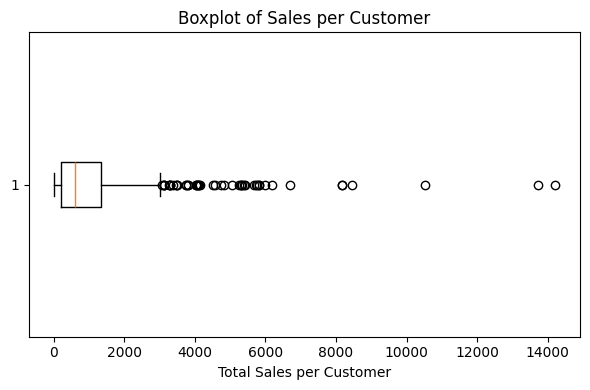

In [8]:
# Plot boxplot of Sales per Customer (to emphasize outliers)
plt.figure(figsize=(6,4))
plt.boxplot(customer_summary["Sales"], vert=False)
plt.xlabel("Total Sales per Customer")
plt.title("Boxplot of Sales per Customer")
plt.tight_layout()
plt.show()

Sales per Customer: Univariate Analysis

The distribution of total sales per customer is heavily right skewed. The majority of customers fall within the lowest sales range, with 449 customers in the first bin alone, followed by a sharp decline in frequency as total sales increase. Only a very small number of customers appear in the higher sales ranges, with isolated customers generating extremely large total sales.

The boxplot further emphasizes this skew by revealing a substantial number of extreme outliers. These outliers represent high value customers whose purchasing behavior differs significantly from the majority. The clustering of outliers suggests revenue concentration rather than isolated anomalies.

This distribution has important modeling implications. The heavy skew and presence of extreme values may violate normality assumptions required by certain parametric models. Transformations such as log scaling may be appropriate for regression based approaches. Additionally, the strong revenue concentration supports segmentation strategies, where high value customers may require distinct recommendation or retention strategies compared to lower spending customers.

### Variable 2: Profit per Customer

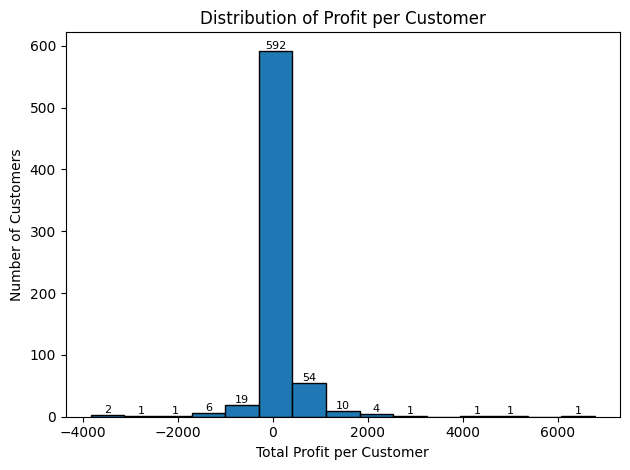

In [9]:
# Plot histogram of Profit per Customer
counts, bins, patches = plt.hist(customer_summary["Profit"], bins=15, edgecolor='black')

for count, patch in zip(counts, patches):
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width()/2, height,
                 int(height),
                 ha='center', va='bottom', fontsize=8)

plt.xlabel("Total Profit per Customer")
plt.ylabel("Number of Customers")
plt.title("Distribution of Profit per Customer")
plt.tight_layout()
plt.show()

Profit per Customer: Univariate Analysis

The distribution of total profit per customer is concentrated near zero, with 592 customers falling within the central profit range. Unlike sales, profit includes both positive and negative values, indicating that some customers generate net losses. The presence of negative profit values suggests the impact of discounts, returns, or low margin product purchases.

While a small number of customers generate substantially positive profit, the majority contribute relatively modest margins. This highlights an important distinction between revenue and profitability. High spending customers are not necessarily the most profitable.

From a modeling perspective, profit may serve as a more meaningful target variable than sales for certain business objectives. However, the presence of negative values and skewness suggests that modeling approaches must account for non normality and potential outliers.

# Dataset 2: Instacart Market Basket Analysis

In [10]:
# Load the dataset
path2 = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path2)

instacart_dir = Path(path2)
print("Instacart dataset folder:", instacart_dir)

# Sampling orders to get a manageable subset of order IDs for loading the large order_products_prior.csv
orders = pd.read_csv(instacart_dir / "orders.csv", usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"])

sample_orders = orders.sample(n=10000, random_state=42)
sample_order_ids = set(sample_orders["order_id"].astype(int))


# Load these files fully as-is
products = pd.read_csv(instacart_dir / "products.csv")

# This file is very large; load only a small sample in chunks to avoid kernel crashes
usecols = ["order_id", "product_id", "add_to_cart_order", "reordered"]

chunks = []
for chunk in pd.read_csv(
    instacart_dir / "order_products__prior.csv",
    usecols=usecols,
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
    chunksize=200_000
):
    filtered = chunk[chunk["order_id"].isin(sample_order_ids)]
    if not filtered.empty:
        chunks.append(filtered)

sample_order_products = pd.concat(chunks, ignore_index=True)

instacart_sample = sample_order_products.merge(products, on="product_id", how="left")

print("Loaded:")
print("orders:", orders.shape)
print("products:", products.shape)
print("instacart_sample:", instacart_sample.shape)

display(orders.head())
display(products.head())
display(instacart_sample.head())

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Instacart dataset folder: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Loaded:
orders: (3421083, 6)
products: (49688, 4)
instacart_sample: (96603, 7)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,322,13819,1,1,Roasted Salted Cashews,117,19
1,322,432,2,1,Vanilla Almond Breeze Almond Milk,91,16
2,322,19311,3,1,Almond Flour Tortillas,128,3
3,322,36646,4,0,Lactose Free Sour Cream,108,16
4,322,28842,5,1,Bunched Cilantro,16,4


### Variable 1: Basket Size (number of products per order)

In [11]:
# Setup Variable
basket_size = instacart_sample.groupby("order_id")["product_id"].count()

basket_size.head()

order_id
322      9
520      9
590      1
816      3
1084    14
Name: product_id, dtype: int64

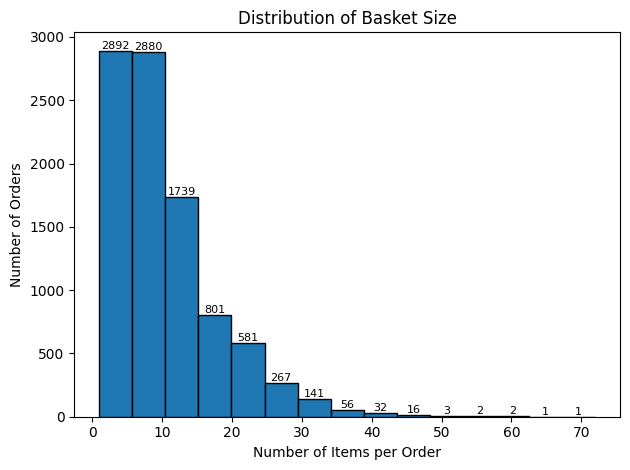

In [12]:
# Plot histogram of Basket Size
counts, bins, patches = plt.hist(basket_size, bins=15, edgecolor='black')

for count, patch in zip(counts, patches):
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width()/2, height,
                 int(height),
                 ha='center', va='bottom', fontsize=8)

plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")
plt.title("Distribution of Basket Size")
plt.tight_layout()
plt.show()

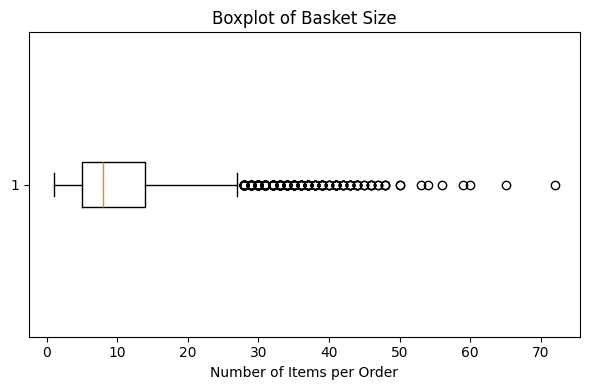

In [13]:
# Plot boxplot of Basket Size
plt.figure(figsize=(6,4))
plt.boxplot(basket_size, vert=False)
plt.xlabel("Number of Items per Order")
plt.title("Boxplot of Basket Size")
plt.tight_layout()
plt.show()

Basket Size: Univariate Analysis

The distribution of basket size is strongly right skewed, with the majority of orders containing fewer than 15 items. The highest concentration of orders appears in the lower item ranges, with sharp declines in frequency as basket size increases. The median basket size appears to fall near the 8 to 10 item range.

The boxplot highlights a substantial number of high item count outliers, with some orders exceeding 60 items. These extreme baskets represent atypical purchasing behavior compared to the majority of routine grocery trips.

This variability has important implications for recommendation modeling. Smaller baskets may reflect targeted purchasing intent, while larger baskets provide richer co purchase signals that strengthen association rule or collaborative filtering approaches. The heavy skew also suggests that modeling techniques should account for imbalance in transaction size, as extreme baskets may disproportionately influence association strength.

### Variable 2: Reorder Flag

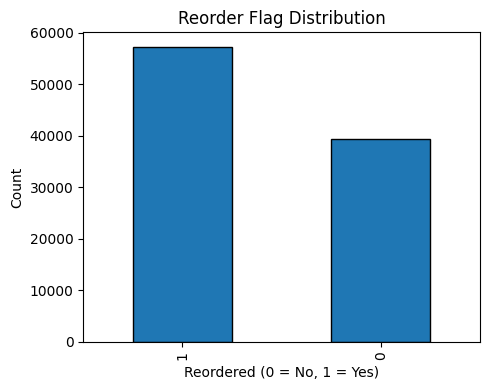

reordered
1    57243
0    39360
Name: count, dtype: int64

In [26]:
reorder_counts = sample_order_products["reordered"].value_counts()

plt.figure(figsize=(5,4))
reorder_counts.plot(kind="bar", edgecolor='black')
plt.xlabel("Reordered (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Reorder Flag Distribution")
plt.tight_layout()
plt.show()

reorder_counts

Reorder Flag: Univariate Analysis

The reorder distribution shows that a majority of purchased items are repeat purchases, with approximately 59% of products marked as reordered. This indicates that grocery purchasing behavior is strongly habitual, with customers frequently repurchasing previously selected items.

The presence of a substantial reorder proportion suggests that past purchase behavior is a powerful predictor of future behavior. From a modeling perspective, this reinforces the value of collaborative filtering and sequence based recommendation approaches, where historical interactions can inform personalized product suggestions.

At the same time, the existence of a sizable portion of non reordered items highlights ongoing product exploration, suggesting that recommendation systems must balance reinforcing habitual purchases with introducing new or complementary products.

# Dataset 3: Amazon Product Reviews (Beauty Products)

In [23]:
# Load Reviews File
reviews = pd.read_json(
    "All_Beauty.jsonl.gz",
    lines=True,
    compression="gzip"
)

#Load Meta Files
meta = pd.read_json(
    "meta_All_Beauty.jsonl.gz",
    lines=True,
    compression="gzip"
)

# Print out df shape
print("All_Beauty Meta Data shape:", meta.shape)
print("All_Beauty Reviews Data shape:", reviews.shape)

# Print head of each df
print("Meta Data:")
display(meta.head())
print("Reviews Data:")
display(reviews.head())

All_Beauty Meta Data shape: (112590, 14)
All_Beauty Reviews Data shape: (701528, 10)
Meta Data:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


Reviews Data:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


### Variable 1: Ratings

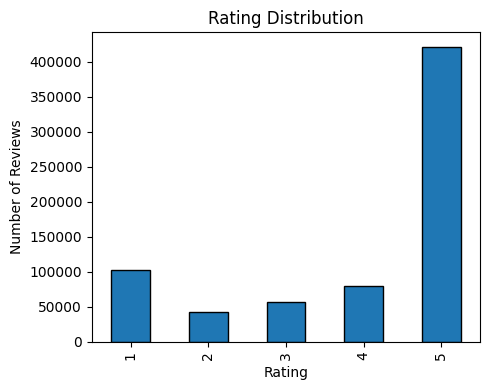

rating
1    102080
2     43034
3     56307
4     79381
5    420726
Name: count, dtype: int64

In [ ]:
# Plot rating distribution
rating_counts = reviews["rating"].value_counts().sort_index()

plt.figure(figsize=(5,4))
rating_counts.plot(kind="bar", edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

rating_counts

Rating Distribution: Univariate Analysis

The rating distribution is heavily skewed toward 5 star reviews, which represent the largest proportion of observations by a substantial margin. One star reviews form the second largest category, while 2 and 3 star reviews are comparatively less frequent. This pattern reflects a polarized review structure common in online retail platforms, where customers are more likely to leave feedback following either very positive or very negative experiences.

From a modeling perspective, this class imbalance presents challenges for supervised learning tasks such as rating prediction or sentiment classification. Models trained on this data may be biased toward predicting higher ratings unless class imbalance techniques such as weighting or resampling are applied. Additionally, the dominance of 5 star reviews may limit the model’s ability to distinguish nuanced differences between moderately positive and highly positive feedback.

### Variable 2: Review Length

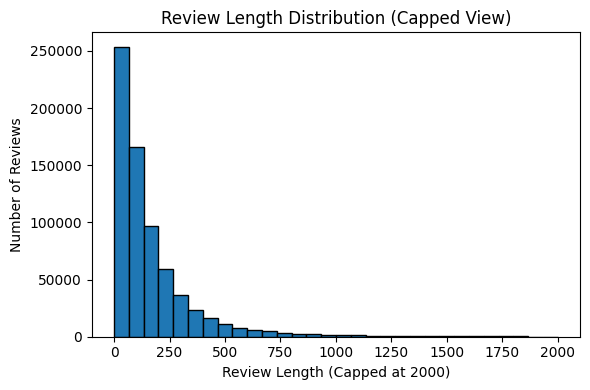

In [ ]:
# Plot histogram of Review Length
reviews["review_length"] = reviews["text"].astype(str).apply(len)

plt.figure(figsize=(6,4))
plt.hist(reviews["review_length"][reviews["review_length"] <= 2000], bins=30, edgecolor='black')
plt.xlabel("Review Length (Capped at 2000)")
plt.ylabel("Number of Reviews")
plt.title("Review Length Distribution (Capped View)")
plt.tight_layout()
plt.show()

Review Length: Univariate Analysis

After capping extreme values for visualization clarity, the review length distribution remains strongly right skewed. The majority of reviews fall under approximately 300 to 400 characters, with a sharp decline in frequency as review length increases. Only a small proportion of reviews exceed 1000 characters.

This pattern suggests that most customers provide concise feedback, while a limited subset contributes more detailed narratives. From a modeling perspective, this variability has implications for natural language processing approaches. Short reviews may provide limited contextual information, while longer reviews may introduce richer sentiment signals. Preprocessing strategies such as truncation, token normalization, or length based feature engineering may therefore be necessary when building recommendation or sentiment models.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

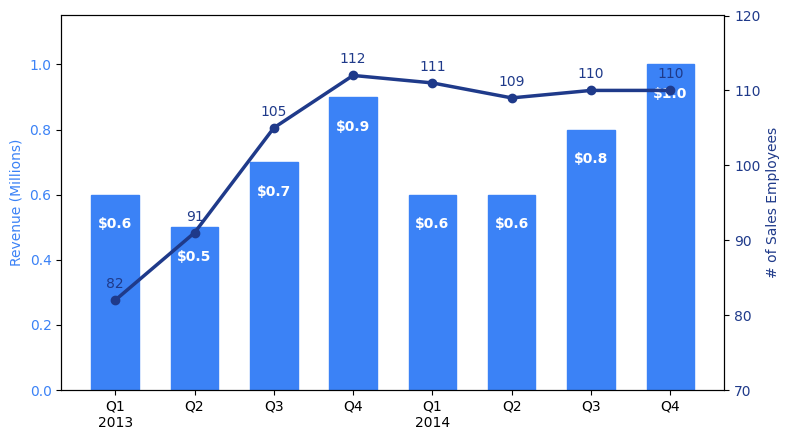

In [32]:
# X axis labels
quarters = ["Q1\n2013", "Q2", "Q3", "Q4", "Q1\n2014", "Q2", "Q3", "Q4"]
x = np.arange(len(quarters))

# Approximate values to match the visual
revenue = [0.6, 0.5, 0.7, 0.9, 0.6, 0.6, 0.8, 1.0]          # in millions
employees = [82, 91, 105, 112, 111, 109, 110, 110]          # count

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# Bars: Revenue
bar_color = "#3b82f6"
bars = ax1.bar(x, revenue, width=0.6, color=bar_color, edgecolor=bar_color)

ax1.set_ylim(0, 1.15)
ax1.set_xticks(x)
ax1.set_xticklabels(quarters)
ax1.set_ylabel("Revenue (Millions)", color=bar_color)
ax1.tick_params(axis="y", labelcolor=bar_color)

# Put revenue labels inside bars
for b, val in zip(bars, revenue):
    ax1.text(
        b.get_x() + b.get_width() / 2,
        val - 0.07,
        f"${val:.1f}",
        ha="center",
        va="top",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

# Line: Employees (twin axis)
ax2 = ax1.twinx()
line_color = "#1f3a8a"
ax2.plot(x, employees, marker="o", linewidth=2.5, color=line_color)
ax2.set_ylim(70, 120)
ax2.set_ylabel("# of Sales Employees", color=line_color)
ax2.tick_params(axis="y", labelcolor=line_color)

# Point labels for employees
for xi, yi in zip(x, employees):
    ax2.text(xi, yi + 1.2, str(yi), ha="center", va="bottom", color=line_color, fontsize=10)


plt.title("")
plt.tight_layout()
plt.show()
